<a href="https://colab.research.google.com/github/ilyannav/Yoga-Screentime-Correlation-Anaylsis-/blob/main/dataset_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
library(readr)
library(dplyr)
yoga <- read_csv("YogaTime.csv")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Rows: 28 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): Date, Week Day
dbl (10): index, Total Screen Time, Social Networking, Reading and Reference...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


"How Does Daily Yoga Impact Screen Time Habits"

Data set from Kagggle by Taylor L Bailey

The relationship between daily yoga practice and screen time usage habits using a Yoga_Screen_Time_Dataset which was collected  about a month. The dataset contains daily observations including total screen time, specific screen usage, such as social networking, productivity, and entertainment, if yoga was done on that day. Each row represents one day of recorded behavior, making the dataset suitable for comparing behavioral differences between yoga and non-yoga days.




What i'm hoping to learn is if doing yoga affects screen time.

In [ ]:
colnames(yoga) <- make.names(colnames(yoga))

colnames(yoga)

[1] "index"                 "Date"                  "Week.Day"             
 [4] "Total.Screen.Time"     "Social.Networking"     "Reading.and.Reference"
 [7] "Other"                 "Productivity"          "Health.and.Fitness"   
[10] "Entertainment"         "Creativity"            "Yoga"

In [ ]:
summary(yoga)

     index           Date             Week.Day         Total.Screen.Time
 Min.   : 0.00   Length:28          Length:28          Min.   : 52.0    
 1st Qu.: 6.75   Class :character   Class :character   1st Qu.: 83.5    
 Median :13.50   Mode  :character   Mode  :character   Median :111.0    
 Mean   :13.50                                         Mean   :113.2    
 3rd Qu.:20.25                                         3rd Qu.:137.2    
 Max.   :27.00                                         Max.   :198.0    
 Social.Networking Reading.and.Reference     Other        Productivity   
 Min.   : 25.00    Min.   : 0.000        Min.   : 0.00   Min.   : 2.000  
 1st Qu.: 41.75    1st Qu.: 2.000        1st Qu.: 4.75   1st Qu.: 3.000  
 Median : 58.00    Median : 5.000        Median : 9.00   Median : 8.000  
 Mean   : 60.71    Mean   : 8.714        Mean   :14.82   Mean   : 9.071  
 3rd Qu.: 76.50    3rd Qu.:13.500        3rd Qu.:21.50   3rd Qu.:15.000  
 Max.   :109.00    Max.   :40.000        Max.

Each row = one day

Columns:

Total.Screen.Time → total minutes


Yoga → 0 or 1 (no yoga vs yoga day)


Other columns = types of screen time content consumed

Such as Social Media Entertainment, Social, Health and Fitness and more

In [ ]:
library(tidyverse)

yoga <- yoga %>%
  mutate(yoga_day = ifelse(Yoga == 1, "Yoga", "No Yoga"))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


This dataset compares the relationship between daily yoga practice and screen time usage by tracking daily behavior over several weeks. The dataset includes variables such as total screen time (measured in minutes), different categories of screen usage (social networking, productivity, and entertainment), and whether yoga was performed on that day.

Each row represents a single day, allowing for comparisons between days with and without yoga practice.


The goal of this analysis was to determine whether practicing yoga is associated with changes in total screen time.


In [ ]:
head(yoga)

index,Date,Week.Day,Total.Screen.Time,Social.Networking,Reading.and.Reference,Other,Productivity,Health.and.Fitness,Entertainment,Creativity,Yoga,yoga_day
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
0,04/17/19,Wednesday,187,89,17,41,22,0,0,0,0,No Yoga
1,04/18/19,Thursday,123,78,17,8,9,0,0,0,0,No Yoga
2,04/19/19,Friday,112,52,40,8,4,0,3,0,0,No Yoga
3,04/20/19,Saturday,101,69,9,38,2,0,3,0,0,No Yoga
4,04/21/19,Sunday,56,35,2,43,3,0,1,1,0,No Yoga
5,04/22/19,Monday,189,68,0,9,3,4,0,0,0,No Yoga


Does practicing yoga reduce total screen time?
How does screen time differ between yoga and non-yoga days?
Does yoga affect specific types of screen use?

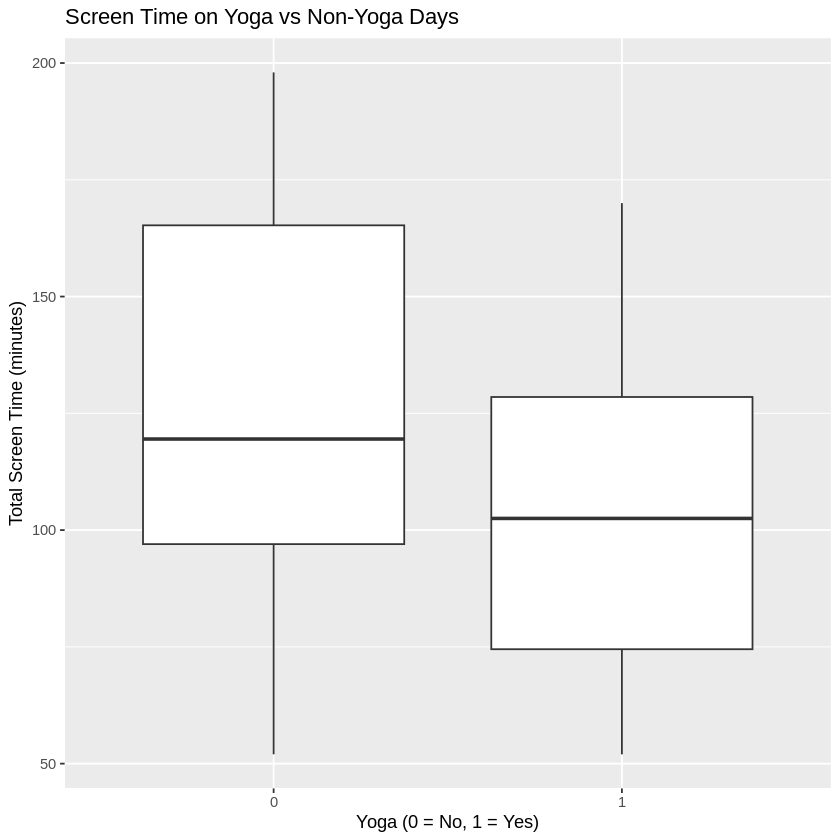

In [ ]:
ggplot(yoga, aes(x = factor(Yoga), y = Total.Screen.Time)) +
  geom_boxplot() +
  labs(
    title = "Screen Time on Yoga vs Non-Yoga Days",
    x = "Yoga (0 = No, 1 = Yes)",
    y = "Total Screen Time (minutes)"
  )

Correlation between daily yoga and screen time is inverse meaning that their seems to be a decrease in screentime when doing yoga compared to not doing yoga

Screen time is goes up when yoga isn't implemented

Screen time goes down when yoga is implemented

Inverse relationship

In [ ]:
yoga %>%
  group_by(yoga_day) %>%
  summarise(
    avg_total_screen = mean(Total.Screen.Time, na.rm = TRUE),
    sd_total_screen = sd(Total.Screen.Time, na.rm = TRUE),
    count = n()
  )

yoga_day,avg_total_screen,sd_total_screen,count
<chr>,<dbl>,<dbl>,<int>
No Yoga,126.0000,49.51217,12
Yoga,103.6875,37.28935,16


This analyzes how screen time differs between days when yoga is practiced and days when it is not. It separates the dataset into two groups based on whether yoga was completed on that day.

 The average total screen time, the variation in screen time from day to day, and the number of days in each group.

 The average gives a general estimate of whether people spend more or less time on screens when they practice yoga, however the standard deviation shows if screen usage is consistent or varies significantly within each group.

 The count ensures that each group has enough data points for a meaningful comparison.

 This data helps determine whether there is a significant variation in screen usage habits between yoga and non-yoga days.


What I learned and found is that doing daily yoga decrease screentime usage according to this data set.



Despite these findings, there are several limitations to consider. The dataset is small and observational, since it was recorded by one person.

There are various confounders in this study which means it can't be certain that doing yoga is the cause of lower screentime usage. Factors, such as day of the week, workload, or personal habits, may also influence screen usage.

Therefore, this dataset can not be generalized for everyone. But this is good for the person to reflect on their own behaviors and how it changes when incorporating yoga into their life.

Overall, this analysis shows that practicing yoga may be associated with reduced screen time, based on this dataset. Further research with more participates would be needed to confirm this relationship.